In [ ]:
!pip install cvxpylayers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 14.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.0/235.0 kB 6.0 MB/s eta 0:00:00


# Cvxpylayers tutorial

Source: https://github.com/cvxgrp/cvxpylayers/blob/master/examples/torch/tutorial.ipynb



In [ ]:
import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import torch
from cvxpylayers.torch import CvxpyLayer
torch.set_default_dtype(torch.double)

np.set_printoptions(precision=3, suppress=True)

## Parametrized convex optimization problem

$$
\begin{array}{ll} \mbox{minimize} & f_0(x;\theta)\\
\mbox{subject to} & f_i(x;\theta) \leq 0, \quad i=1, \ldots, m\\
& A(\theta)x=b(\theta),
\end{array}
$$
with variable $x \in \mathbf{R}^n$ and parameters $\theta\in\Theta\subseteq\mathbf{R}^p$

* objective and inequality constraints $f_0, \ldots, f_m$ are *convex* in $x$ for each $\theta$, *i.e.*, their graphs curve upward
* equality constraints are linear
* for a given value of $\theta$, find a value for $x$ that minimizes objective, while satisfying constraints
* we can efficiently solve these globally with near total reliability

## Solution map
* Solution $x^\star$ is an implicit function of $\theta$
* When unique, define solution map as function
$x^\star = \mathcal S(\theta)$
* Need to call numerical solver to evaluate
* This function is often differentiable
* In a series of papers we showed how to analytically differentiate this function, using the implicit function theorem
* Benefits of analytical differentiation: works with nonsmooth objective/constraints, low memory usage, don't compound errors

## CVXPY
* High level domain-specific language (DSL) for convex optimization
* Define variables, parameters, objective and constraints
* Synthesize into problem object, then call solve method
* We've added derivatives to CVXPY (forward and backward)

## CVXPYlayers
![](https://github.com/cvxgrp/cvxpylayers/blob/master/cvxpylayers_logo.png?raw=true)
* Convert CVXPY problems into callable, differentiable Pytorch and Tensorflow modules in one line

## Applications
* learning convex optimization models (structured prediction): https://stanford.edu/~boyd/papers/learning_copt_models.html
* learning decision-making policies (reinforcement learning): https://stanford.edu/~boyd/papers/learning_cocps.html
* machine learning hyper-parameter tuning and feature engineering: https://stanford.edu/~boyd/papers/lsat.html
* repairing infeasible or unbounded optimization problems: https://stanford.edu/~boyd/papers/auto_repair_cvx.html
* as protection layers in neural networks: http://physbam.stanford.edu/~fedkiw/papers/stanford2019-10.pdf
* custom neural network layers (sparsemax, csoftmax, csparsemax, LML): https://locuslab.github.io/2019-10-28-cvxpylayers/
* and many more...

## Average example
Find the average of a vector:
\begin{equation}
\begin{array}{ll}
\mbox{minimize} & \sum_{i=1}^n (y_i - x)^2
\end{array}
\end{equation}
Variable $x$, parameters $y\in\mathbf{R}^n$

The solution map is clearly:
$$x=\sum_{i=1}^n y_i / n$$

In [ ]:
n = 7

# Define variables & parameters
x = cp.Variable()
y = cp.Parameter(n)

# Define objective and constraints
objective = cp.sum_squares(y - x)
constraints = []

# Synthesize problem
prob = cp.Problem(cp.Minimize(objective), constraints)

# Set parameter values
y.value = np.random.randn(n)

# Solve problem in one line
prob.solve(requires_grad=True)
print("solution:", "%.3f" % x.value)
print("analytical solution:", "%.3f" % np.mean(y.value))

solution: -0.367
analytical solution: -0.367


The gradient is simply:
$$\nabla_y x = (1/n)\mathbf{1}$$

In [ ]:
# Set gradient wrt x
x.gradient = np.array([1.])

# Differentiate in one line
prob.backward()
print("gradient:", y.gradient)
print("analytical gradient:", np.ones(y.size) / n)

gradient: [0.143 0.143 0.143 0.143 0.143 0.143 0.143]
analytical gradient: [0.143 0.143 0.143 0.143 0.143 0.143 0.143]


## Median example
Finding the median of a vector:
\begin{equation}
\begin{array}{ll}
\mbox{minimize} & \sum_{i=1}^n |y_i - x|,
\end{array}
\end{equation}
Variable $x$, parameters $y\in\mathbf{R}^n$

Solution:
$$x=\mathbf{median}(y)$$

Gradient (no duplicates):
$$(\nabla_y x)_i = \begin{cases}
1 & y_i = \mathbf{median}(y) \\
0 & \text{otherwise}.
\end{cases}$$

In [ ]:
n = 7

# Define variables & parameters
x = cp.Variable()
y = cp.Parameter(n)

# Define objective and constraints
objective = cp.norm1(y - x)
constraints = []

# Synthesize problem
prob = cp.Problem(cp.Minimize(objective), constraints)

# Set parameter values
y.value = np.random.randn(n)

# Solve problem in one line
prob.solve(requires_grad=True)
print("solution:", "%.3f" % x.value)
print("analytical solution:", "%.3f" % np.median(y.value))

solution: -0.106
analytical solution: -0.106


In [ ]:
# Set gradient wrt x
x.gradient = np.array([1.])

# Differentiate in one line
prob.backward()
print("gradient:", y.gradient)
g = np.zeros(y.size)
g[y.value == np.median(y.value)] = 1.
print("analytical gradient:", g)

gradient: [ 0. -0. -0.  1.  0.  0. -0.]
analytical gradient: [0. 0. 0. 1. 0. 0. 0.]


## ReLU activation example

The ReLU activation function is given by $\sigma(x) = \max \{ x, 0\}$. The derivative is given by
\begin{align}
\sigma'(x) = \begin{cases}
1 & x \geq 0 \\
0 & x < 0
\end{cases}.
\end{align}



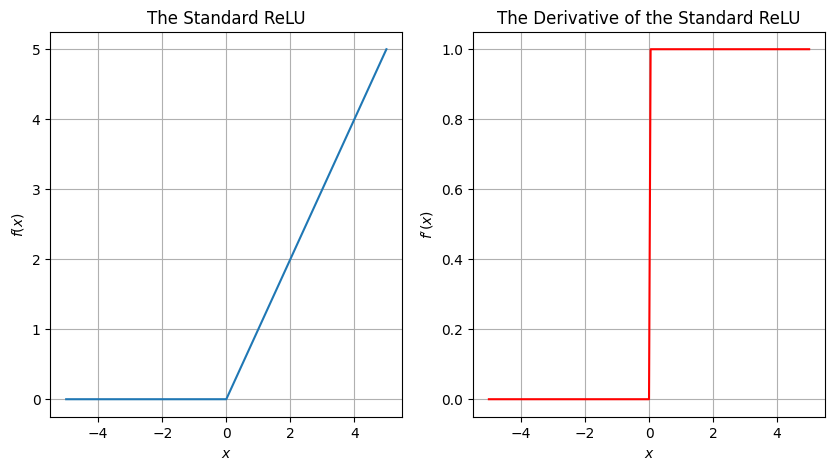

In [ ]:
n = 201
x = torch.linspace(-5, 5, steps=n, requires_grad=True)
y = torch.relu(x)

plt.figure(figsize=(10, 5))  # Set the figure size for better visibility

plt.subplot(1, 2, 1)  # Define subplot 1 in a 1x2 layout
plt.plot(x.detach().numpy(), y.detach().numpy(), label='ReLU')
plt.title('The Standard ReLU')
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.grid(True)




y.sum().backward()

plt.subplot(1, 2, 2)  # Define subplot 2 in a 1x2 layout
plt.plot(x.detach().numpy(), x.grad.detach().numpy(), label='Derivative', color='r')
plt.title('The Derivative of the Standard ReLU')
plt.xlabel('$x$')
plt.ylabel('$f\'(x)$')
plt.grid(True)

ReLU function $\sigma(x) $ can be written as the solution to the following constraint optimization problem:
\begin{align}
\min _{y} \frac{1}{2} \| y - x\|^2 , \qquad \text{subject to}~~ y \geq 0 .
\end{align}
Thus, we can use cvxpy to compute ReLU and differentiate it using cvxpylayer.

### Use Cvxpylayer

Use `layer = CvxpyLayer(prob, parameters=[_x], variables=[_y]) ` to construct the neural network layer, where the input is `parameters` and the output is `y`.

```
x = torch.linspace(-5, 5, steps=n, requires_grad=True)
y, = layer(x)
y.sum().backward()
```
Then `x.grad` is the gradient $\nabla_{x}  y^*(x)$, where $y^*(x)$ is the solution to the optimization problem when the parameter is $x$.



Text(0, 0.5, "$f'(x)$")

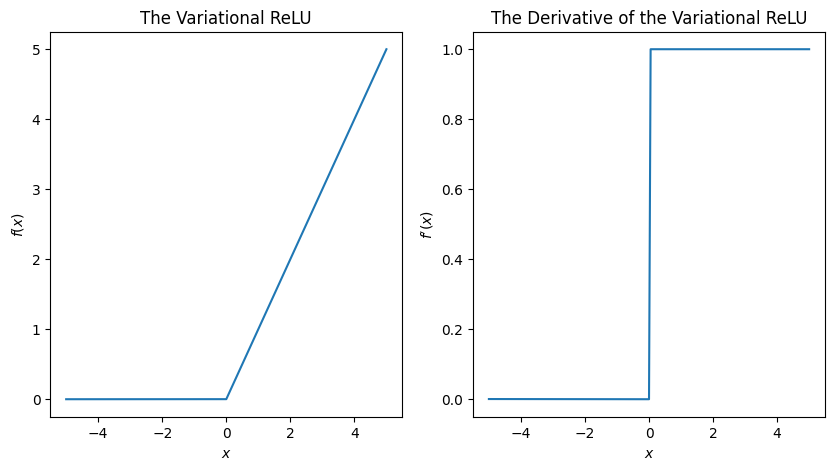

In [ ]:
_x = cp.Parameter(n)
_y = cp.Variable(n)
obj = cp.Minimize(cp.sum_squares(_y-_x))
cons = [_y >= 0]
prob = cp.Problem(obj, cons)
layer = CvxpyLayer(prob, parameters=[_x], variables=[_y])
# create a cvxpy layer -- input = parameter, output = solution

x = torch.linspace(-5, 5, steps=n, requires_grad=True)
y, = layer(x)
y.sum().backward() # x.grad = gradient of y with respect to x


plt.figure(figsize=(10, 5))  # Set the figure size for better visibility

plt.subplot(1, 2, 1)  # Define subplot 1 in a 1x2 layout
plt.plot(x.detach().numpy(), y.detach().numpy())
plt.title('The Variational ReLU')
plt.xlabel('$x$')
plt.ylabel('$f(x)$')

plt.subplot(1, 2, 2)
plt.plot(x.detach().numpy(), x.grad.detach().numpy())
plt.title('The Derivative of the Variational ReLU')
plt.xlabel('$x$')
plt.ylabel('$f\'(x)$')



## Finding the optimal tuning parameter of Lasso Regression




Given the training data, for each $\lambda$, we get the solution $\beta(\lambda)$ as a function of $\lambda$.

### Optimize $\lambda$ by gradient descent

Then we can evaluate the performance of $\lambda$ on the evaluation dataset, compute the loss as a function of $\lambda$. Then minimize it by gradient descent.


### Generate data

In [ ]:
import numpy as np

np.random.seed(0)
n_samples_train = 50
n_samples_test = 200
n_features = 100

# Generate synthetic data
X = np.random.randn(n_samples_train, n_features)

true_coef = 3*np.ones(n_features,)
# Use sparse true coefficients
true_coef[5:] = 0  # Make only the first 100 coefficients non-zero
y = X @ true_coef + np.random.normal(0, 1, size=n_samples_train)  # Add some noise


In [ ]:
import cvxpy as cp

# Define the Lasso regularization parameter as a CVXPY parameter
lambda_param = cp.Parameter(nonneg=True)

# Coefficients of the regression model
w = cp.Variable(n_features)

# Objective: Minimize the mean squared error + lambda * L2-norm of w
objective = cp.Minimize(0.5 * cp.norm2(X @ w - y)**2 / n_samples_train + lambda_param * cp.norm1(w))

# Define the problem
problem = cp.Problem(objective)

lasso_layer = CvxpyLayer(problem, parameters=[lambda_param], variables=[w])

### Run gradient descent on the loss function of the solution with parameter $\lambda$ on the test data



Iteration 0, Loss: 24.408531188964844, Lambda: 1.7959823608398438, Gradient of Lambda: tensor([20.4018], dtype=torch.float32)
Iteration 1, Loss: 20.503110885620117, Lambda: 1.5979502201080322, Gradient of Lambda: tensor([19.8032], dtype=torch.float32)
Iteration 2, Loss: 16.51531410217285, Lambda: 1.4335010051727295, Gradient of Lambda: tensor([16.4449], dtype=torch.float32)
Iteration 3, Loss: 13.759081840515137, Lambda: 1.2778069972991943, Gradient of Lambda: tensor([15.5694], dtype=torch.float32)
Iteration 4, Loss: 11.195661544799805, Lambda: 1.1422004699707031, Gradient of Lambda: tensor([13.5607], dtype=torch.float32)
Iteration 5, Loss: 9.640021324157715, Lambda: 1.0140471458435059, Gradient of Lambda: tensor([12.8153], dtype=torch.float32)
Iteration 6, Loss: 8.039166450500488, Lambda: 0.8996601700782776, Gradient of Lambda: tensor([11.4387], dtype=torch.float32)
Iteration 7, Loss: 6.818113327026367, Lambda: 0.7950997948646545, Gradient of Lambda: tensor([10.4560], dtype=torch.float

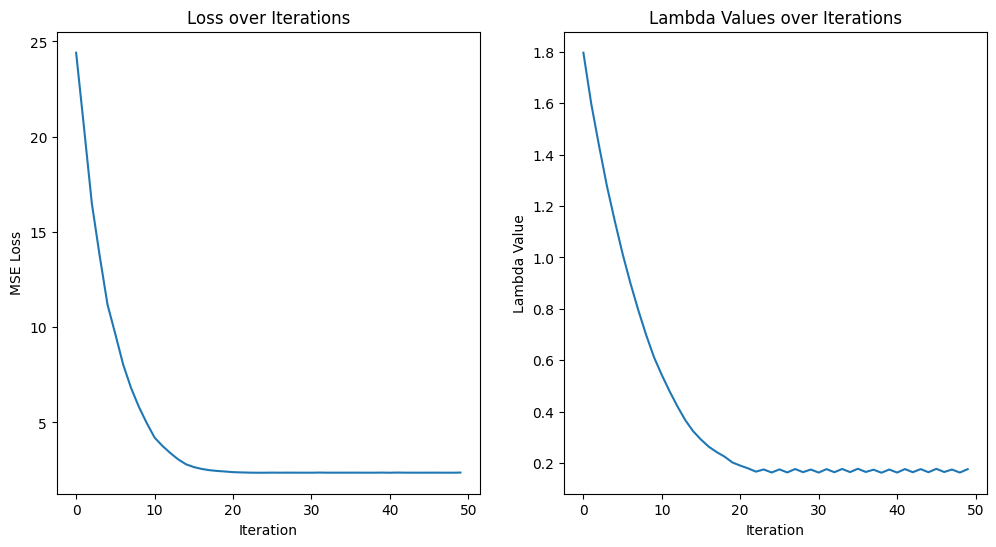

In [ ]:
import torch
from torch.optim import SGD

# Convert data to PyTorch tensors

X_test = np.random.randn(n_samples_test, n_features)
y_test = X_test @ true_coef + np.random.normal(0, 1, size=n_samples_test)  # Add some noise

X_test_torch = torch.tensor(X_test, dtype=torch.float32)
y_test_torch = torch.tensor(y_test, dtype=torch.float32)

# Initialize lambda as a trainable parameter
lambda_torch = torch.tensor([2.0], dtype=torch.float32, requires_grad=True)

# Optimizer
optimizer = SGD([lambda_torch], lr=0.01)

# Store the values for plotting
lambda_values = []
loss_values = []

for iteration in range(50):
    optimizer.zero_grad()

    # Solve the Lasso problem
    w_opt = lasso_layer(lambda_torch)[0]

    w_opt = w_opt.view(-1, 1)
    # Compute the MSE loss for monitoring
    loss = torch.mean((X_test_torch @ w_opt - y_test_torch.view(-1,1)) ** 2)

    # Backward pass to compute gradient of loss w.r.t. lambda
    loss.backward()

    gradient_of_C = lambda_torch.grad
    # Update lambda
    optimizer.step()

    # Log data
    lambda_values.append(lambda_torch.item())
    loss_values.append(loss.item())
    print(f"Iteration {iteration}, Loss: {loss.item()}, Lambda: {lambda_torch.item()}, Gradient of Lambda: {lambda_torch.grad}")




import matplotlib.pyplot as plt

# Plotting loss over iterations
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(loss_values)
plt.title('Loss over Iterations')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')

# Plotting lambda values over iterations
plt.subplot(1, 2, 2)
plt.plot(lambda_values)
plt.title('Lambda Values over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Lambda Value')

plt.show()



Lambda: 0.0001, Loss: 3.6264142990112305
Lambda: 0.00012067926406393288, Loss: 3.580287456512451
Lambda: 0.00014563484775012445, Loss: 3.600632905960083
Lambda: 0.00017575106248547912, Loss: 3.595369815826416
Lambda: 0.00021209508879201905, Loss: 3.5608301162719727
Lambda: 0.0002559547922699536, Loss: 3.566256046295166
Lambda: 0.00030888435964774815, Loss: 3.5706586837768555
Lambda: 0.0003727593720314938, Loss: 3.585796594619751
Lambda: 0.0004498432668969444, Loss: 3.646317958831787
Lambda: 0.0005428675439323859, Loss: 3.570601463317871
Lambda: 0.0006551285568595509, Loss: 3.566788911819458
Lambda: 0.0007906043210907702, Loss: 3.568295955657959
Lambda: 0.0009540954763499944, Loss: 3.602210760116577
Lambda: 0.0011513953993264468, Loss: 3.5819356441497803
Lambda: 0.0013894954943731374, Loss: 3.5667788982391357
Lambda: 0.0016768329368110067, Loss: 3.5713675022125244
Lambda: 0.0020235896477251557, Loss: 3.5787038803100586
Lambda: 0.0024420530945486497, Loss: 3.5847079753875732
Lambda: 0.00

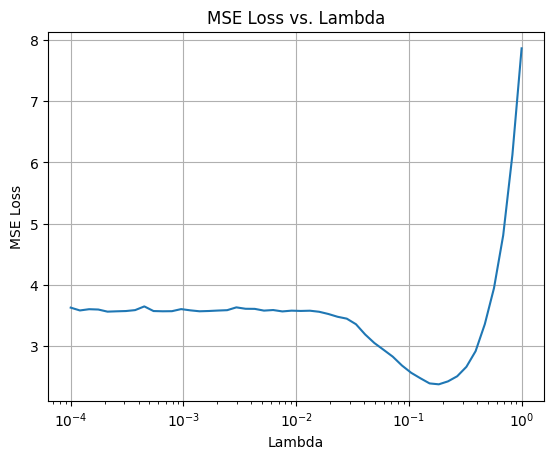

In [ ]:
import numpy as np
import torch

# Assume X_test, y_test are defined and converted to PyTorch tensors
X_test_torch = torch.tensor(X_test, dtype=torch.float32)
y_test_torch = torch.tensor(y_test, dtype=torch.float32)

# Define a range of lambda values for grid search
lambda_values = np.logspace(-4, 0, num=50)  # from 0 to 2 in 50 steps
loss_values = []

# Perform the grid search
for lambda_val in lambda_values:
    lambda_torch = torch.tensor([lambda_val], dtype=torch.float32)  # set current lambda

    # Solve the Lasso problem with current lambda
    w_opt = lasso_layer(lambda_torch)[0]

    # Reshape w_opt for matrix multiplication
    w_opt = w_opt.view(-1, 1)

    # Compute the MSE loss for the current lambda
    loss = torch.mean((X_test_torch @ w_opt - y_test_torch.view(-1, 1)) ** 2)

    # Store the loss value
    loss_values.append(loss.item())

    print(f"Lambda: {lambda_val}, Loss: {loss.item()}")

# Find the lambda with the minimum loss
min_loss_index = np.argmin(loss_values)
best_lambda = lambda_values[min_loss_index]
best_loss = loss_values[min_loss_index]

print(f"Best Lambda: {best_lambda}, Best Loss: {best_loss}")

# Optionally, plot the results
import matplotlib.pyplot as plt

plt.figure()
plt.semilogx(lambda_values, loss_values)
plt.xlabel('Lambda')
plt.ylabel('MSE Loss')
plt.title('MSE Loss vs. Lambda')
plt.grid(True)
plt.show()
